Responses rows: 50
recognition_group
Middle    23
High      21
Low        6
Name: count, dtype: int64
long_df shape: (550, 5)
subjects: 50 items: 11

=== All foods / All subjects (No GPA) ===
n_subjects = 50
1D Stress-1 = 0.542
2D Stress-1 = 0.148
3D Stress-1 = 0.086


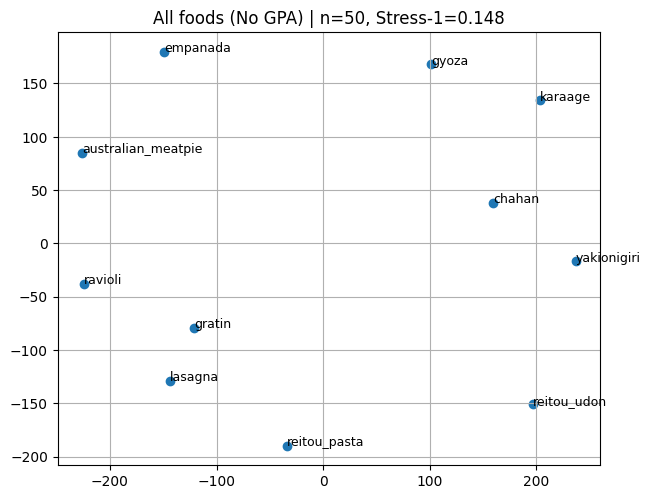


=== By recognition_group (No GPA) ===

[Low] n_subjects=6
  1D Stress-1 = 0.406
  2D Stress-1 = 0.154
  3D Stress-1 = 0.068

[Middle] n_subjects=23
  1D Stress-1 = 0.552
  2D Stress-1 = 0.130
  3D Stress-1 = 0.072

[High] n_subjects=21
  1D Stress-1 = 0.535
  2D Stress-1 = 0.156
  3D Stress-1 = 0.091


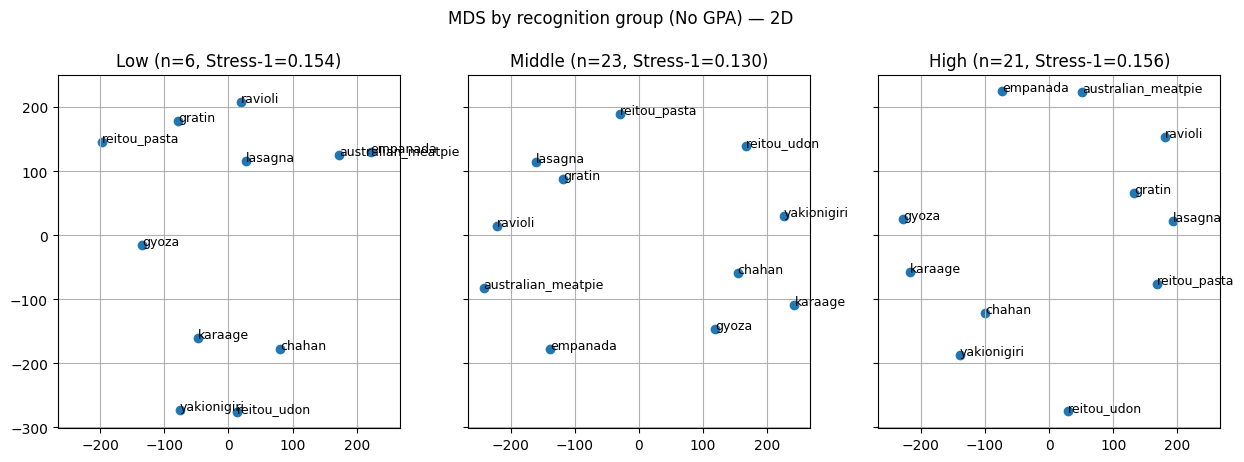


=== GPA (reference only) ===
n_subjects = 50
1D Stress-1 = 0.542
2D Stress-1 = 0.148
3D Stress-1 = 0.088


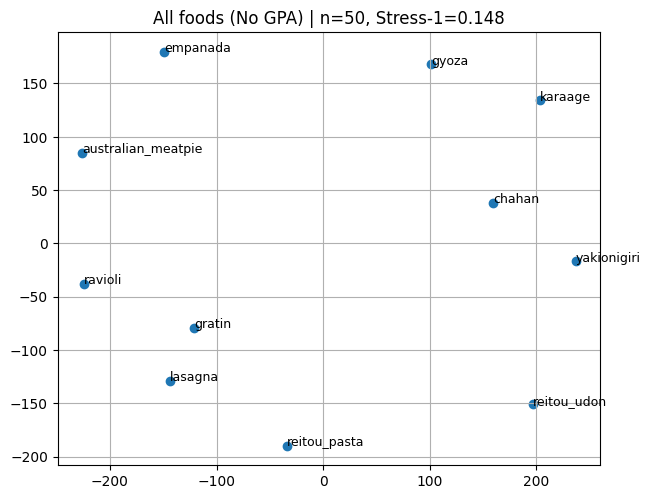

In [20]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import MDS
from scipy.linalg import orthogonal_procrustes


# =========================
# 0) 入力パス
# =========================
csv_path = Path("/Users/sammy/Desktop/Chu-o/経済学研究科/ゼミ/２年/研究2025/データ/Responses.csv")


# =========================
# 1) Responses.csv 読み込み
# =========================
USE_COLS = [
    "submission_id",
    "moveHistory_json",
    "recognition:australian_meatpie",
    "recognition_group",
]
df = pd.read_csv(csv_path, usecols=lambda c: c in USE_COLS)

# recognition_group が空の行は落とす（分類が必要なので）
df = df.dropna(subset=["submission_id", "moveHistory_json", "recognition_group"]).copy()
df["subject"] = df["submission_id"].astype(str)

print("Responses rows:", len(df))
print(df["recognition_group"].value_counts(dropna=False))


# =========================
# 2) moveHistory_json → 最終配置 long_df
# =========================
def build_long_from_movehistory(df: pd.DataFrame) -> pd.DataFrame:
    """
    moveHistory_json 内のイベントから、各itemの「最後の座標」を拾う。
    出力：long_df (subject, item, x, y, recognition_group)
    """
    records = []

    for _, row in df.iterrows():
        subject = str(row["subject"])
        group = str(row["recognition_group"])

        js = row["moveHistory_json"]
        if not isinstance(js, str) or not js.strip():
            continue

        try:
            events = json.loads(js)
        except Exception:
            continue

        if not isinstance(events, list):
            continue

        last = {}  # item -> (x,y)

        for ev in events:
            if not isinstance(ev, dict):
                continue

            name = ev.get("target")
            pos = ev.get("position")

            if name is None or not isinstance(pos, dict):
                continue

            x = pos.get("x")
            y = pos.get("y")
            if x is None or y is None:
                continue

            try:
                last[str(name)] = (float(x), float(y))
            except Exception:
                continue

        for item, (x, y) in last.items():
            records.append({
                "subject": subject,
                "item": item,
                "x": x,
                "y": y,
                "recognition_group": group,
            })

    long_df = pd.DataFrame.from_records(records)
    if long_df.empty:
        raise ValueError("moveHistory_json から座標が1件も取れませんでした。")

    long_df["x"] = pd.to_numeric(long_df["x"], errors="coerce")
    long_df["y"] = pd.to_numeric(long_df["y"], errors="coerce")
    long_df = long_df.dropna(subset=["subject", "item", "x", "y", "recognition_group"])

    return long_df


long_df = build_long_from_movehistory(df)
print("long_df shape:", long_df.shape)
print("subjects:", long_df["subject"].nunique(), "items:", long_df["item"].nunique())


# =========================
# 3) 距離行列関連
# =========================
def subj_distance(mat: np.ndarray) -> np.ndarray:
    """
    mat: (m, d)  item座標
    return: (m, m) 距離行列
    """
    m = mat.shape[0]
    D = np.zeros((m, m))
    for i in range(m):
        for j in range(i + 1, m):
            D[i, j] = D[j, i] = np.linalg.norm(mat[i] - mat[j])
    return D


def stress1(Dhat: np.ndarray, Dbar: np.ndarray) -> float:
    """
    Stress-1（正規化 stress）
    Stress-1 = sqrt( sum_{i<j}(dhat_ij - dbar_ij)^2 / sum_{i<j} dbar_ij^2 )
    対称行列なので全要素で計算しても比は同じ（2倍になるだけ）→OK
    """
    num = np.sum((Dhat - Dbar) ** 2)
    den = np.sum(Dbar ** 2)
    return float(np.sqrt(num / den))


# =========================
# 4) 【主分析】GPAなし MDS（1D/2D/3Dをまとめて返す）
# =========================
def mds_no_gpa_multi_dim(
    long_df_in: pd.DataFrame,
    dims=(1, 2, 3),
    random_state=0,
    n_init=8,
    max_iter=300,
):
    """
    long_df_in: ある集合（全体/群別/洋食のみ等）の long_df
    - 被験者ごとに距離行列
    - 平均距離行列 Dbar
    - Dbar に対して MDS
    戻り値:
      results[d] = {"X": X_d, "stress1": Stress1_d}
      items, n_subjects, Dbar
    """
    items = sorted(long_df_in["item"].unique())
    subjects = sorted(long_df_in["subject"].unique())

    mats = []
    used_subjects = []

    # 全itemが揃っているsubjectのみを使う
    item_set = set(items)

    for sub in subjects:
        sub_df = long_df_in[long_df_in["subject"] == sub].set_index("item")
        if not item_set.issubset(sub_df.index):
            continue

        XY = sub_df.loc[items, ["x", "y"]].values.astype(float)
        mats.append(XY)
        used_subjects.append(sub)

    n_subjects = len(used_subjects)
    if n_subjects < 2:
        raise ValueError("MDSに使える被験者が少なすぎます（全item揃ってるか確認）")

    Ds = np.stack([subj_distance(m) for m in mats], axis=0)  # (n, m, m)
    Dbar = Ds.mean(axis=0)                                  # (m, m)

    results = {}
    for d in dims:
        mds = MDS(
            n_components=d,
            dissimilarity="precomputed",
            random_state=random_state,
            n_init=n_init,
            max_iter=max_iter,
        )
        X = mds.fit_transform(Dbar)
        Dhat = subj_distance(X)
        s1 = stress1(Dhat, Dbar)

        results[d] = {"X": X, "stress1": s1}

    return results, items, n_subjects, Dbar


# =========================
# 5) 全体（全食品・全被験者）MDS 1/2/3次元
# =========================
res_all, items_all, n_all, Dbar_all = mds_no_gpa_multi_dim(long_df, dims=(1, 2, 3))

print("\n=== All foods / All subjects (No GPA) ===")
print(f"n_subjects = {n_all}")
for d in [1, 2, 3]:
    print(f"{d}D Stress-1 = {res_all[d]['stress1']:.3f}")


# 2D 図（全体）
X2_all = res_all[2]["X"]
plt.figure(figsize=(7, 7))
plt.scatter(X2_all[:, 0], X2_all[:, 1])
for i, it in enumerate(items_all):
    plt.text(X2_all[i, 0], X2_all[i, 1], it, fontsize=9)
plt.title(f"All foods (No GPA) | n={n_all}, Stress-1={res_all[2]['stress1']:.3f}")
plt.gca().set_aspect("equal")
plt.grid(True)
plt.show()


# =========================
# 6) 認知度別（Low/Middle/High）MDS 1/2/3次元
# =========================
group_results = {}

print("\n=== By recognition_group (No GPA) ===")
for g in ["Low", "Middle", "High"]:
    df_g = long_df[long_df["recognition_group"] == g].copy()

    res_g, items_g, n_g, Dbar_g = mds_no_gpa_multi_dim(df_g, dims=(1, 2, 3))
    group_results[g] = {"res": res_g, "items": items_g, "n": n_g, "Dbar": Dbar_g}

    print(f"\n[{g}] n_subjects={n_g}")
    for d in [1, 2, 3]:
        print(f"  {d}D Stress-1 = {res_g[d]['stress1']:.3f}")


# 2D 図（群別を横並び）
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, g in zip(axes, ["Low", "Middle", "High"]):
    X = group_results[g]["res"][2]["X"]
    s1 = group_results[g]["res"][2]["stress1"]
    items = group_results[g]["items"]
    n = group_results[g]["n"]

    ax.scatter(X[:, 0], X[:, 1])
    for i, it in enumerate(items):
        ax.text(X[i, 0], X[i, 1], it, fontsize=9)

    ax.set_title(f"{g} (n={n}, Stress-1={s1:.3f})")
    ax.set_aspect("equal")
    ax.grid(True)

plt.suptitle("MDS by recognition group (No GPA) — 2D")

# === 保存（論文用）===
out_path = Path("image_file_chuo_group.png")
plt.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()



# =========================
# 7) （補足）GPAを一応やってみた（最後に置く）
#     ※主分析には使わない
# =========================
def run_gpa_scaled(long_df_in: pd.DataFrame, max_iter: int = 30):
    """
    Similarity GPA（中心化＋スケール正規化＋回転）
    - subject間で座標系を揃える
    - 最後に整列後の距離平均 Dbar を作って MDS
    """
    items = sorted(long_df_in["item"].unique())
    subjects = sorted(long_df_in["subject"].unique())
    item_set = set(items)

    mats = []
    used_subjects = []

    for sub in subjects:
        sub_df = long_df_in[long_df_in["subject"] == sub].set_index("item")
        if not item_set.issubset(sub_df.index):
            continue

        XY = sub_df.loc[items, ["x", "y"]].values.astype(float)

        # 中心化
        XY = XY - XY.mean(axis=0, keepdims=True)
        # スケール正規化
        nrm = np.linalg.norm(XY)
        if nrm == 0:
            continue
        XY = XY / nrm

        mats.append(XY)
        used_subjects.append(sub)

    if len(mats) < 2:
        raise ValueError("GPAに使えるsubjectが少なすぎます")

    template = mats[0]

    for _ in range(max_iter):
        aligned = []
        for XY in mats:
            R, _ = orthogonal_procrustes(XY, template)
            aligned.append(XY @ R)

        new_template = np.mean(aligned, axis=0)
        new_template -= new_template.mean(axis=0, keepdims=True)
        new_template /= np.linalg.norm(new_template)

        if np.linalg.norm(template - new_template) < 1e-6:
            template = new_template
            mats = aligned
            break

        template = new_template
        mats = aligned

    # 整列後距離の平均
    Ds = np.stack([subj_distance(m) for m in mats], axis=0)
    Dbar = Ds.mean(axis=0)

    return Dbar, items, len(used_subjects)


def mds_from_Dbar(Dbar, dims=(1, 2, 3), random_state=0, n_init=8, max_iter=300):
    out = {}
    for d in dims:
        mds = MDS(
            n_components=d,
            dissimilarity="precomputed",
            random_state=random_state,
            n_init=n_init,
            max_iter=max_iter,
        )
        X = mds.fit_transform(Dbar)
        out[d] = {"X": X, "stress1": stress1(subj_distance(X), Dbar)}
    return out


print("\n=== GPA (reference only) ===")
Dbar_gpa, items_gpa, n_gpa = run_gpa_scaled(long_df)
res_gpa = mds_from_Dbar(Dbar_gpa, dims=(1, 2, 3))

print(f"n_subjects = {n_gpa}")
for d in [1, 2, 3]:
    print(f"{d}D Stress-1 = {res_gpa[d]['stress1']:.3f}")

# GPA 2D 図（参考）
X2_gpa = res_gpa[2]["X"]
plt.figure(figsize=(7, 7))
plt.scatter(X2_all[:, 0], X2_all[:, 1])
for i, it in enumerate(items_all):
    plt.text(X2_all[i, 0], X2_all[i, 1], it, fontsize=9)

plt.title(f"All foods (No GPA) | n={n_all}, Stress-1={res_all[2]['stress1']:.3f}")
plt.gca().set_aspect("equal")
plt.grid(True)

# === 保存（論文用）===
out_path = Path("image_file_chuo.png")
plt.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()



In [2]:
WESTERN_ITEMS = [
    "australian_meatpie",
    "empanada",
    "lasagna",
    "gratin",
    "ravioli",
    "reitou_pasta",
]

In [3]:
long_df_western = long_df[long_df["item"].isin(WESTERN_ITEMS)].copy()

print("Western-only long_df shape:", long_df_western.shape)
print("subjects:", long_df_western["subject"].nunique())
print("items:", long_df_western["item"].unique())


Western-only long_df shape: (300, 5)
subjects: 50
items: ['empanada' 'gratin' 'lasagna' 'australian_meatpie' 'ravioli'
 'reitou_pasta']


In [4]:
res_w_all, items_w, n_w, _ = mds_no_gpa_multi_dim(
    long_df_western, dims=(1,2,3)
)

print("\n=== Western only / All subjects ===")
print(f"n_subjects = {n_w}")
for d in [1,2,3]:
    print(f"{d}D Stress-1 = {res_w_all[d]['stress1']:.3f}")



=== Western only / All subjects ===
n_subjects = 50
1D Stress-1 = 0.454
2D Stress-1 = 0.142
3D Stress-1 = 0.077


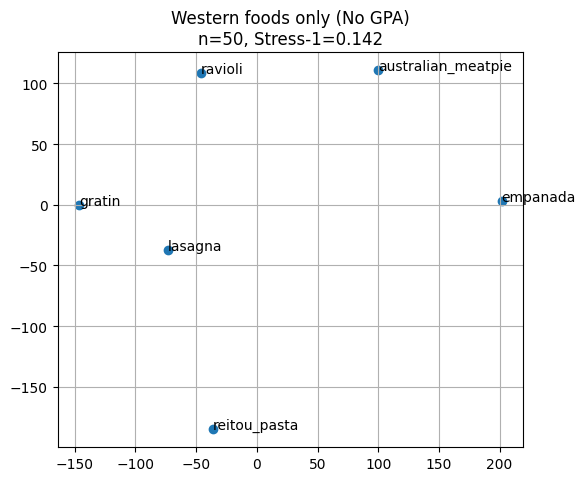

In [21]:
X2 = res_w_all[2]["X"]

plt.figure(figsize=(6,6))
plt.scatter(X2[:,0], X2[:,1])
for i, it in enumerate(items_w):
    plt.text(X2[i,0], X2[i,1], it, fontsize=10)

plt.title(
    f"Western foods only (No GPA)\n"
    f"n={n_w}, Stress-1={res_w_all[2]['stress1']:.3f}"
)
plt.gca().set_aspect("equal")
plt.grid(True)

# === 保存（論文用）===
out_path = Path("image_file_chuo_western.png")
plt.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


In [6]:
western_group_results = {}

print("\n=== Western only / by recognition_group ===")

for g in ["Low", "Middle", "High"]:
    df_g = long_df_western[long_df_western["recognition_group"] == g]

    res_g, items_g, n_g, _ = mds_no_gpa_multi_dim(df_g, dims=(1,2,3))
    western_group_results[g] = {
        "res": res_g,
        "items": items_g,
        "n": n_g
    }

    print(f"\n[{g}] n_subjects={n_g}")
    for d in [1,2,3]:
        print(f"  {d}D Stress-1 = {res_g[d]['stress1']:.3f}")



=== Western only / by recognition_group ===

[Low] n_subjects=6
  1D Stress-1 = 0.454
  2D Stress-1 = 0.143
  3D Stress-1 = 0.007

[Middle] n_subjects=23
  1D Stress-1 = 0.463
  2D Stress-1 = 0.115
  3D Stress-1 = 0.057

[High] n_subjects=21
  1D Stress-1 = 0.447
  2D Stress-1 = 0.148
  3D Stress-1 = 0.072


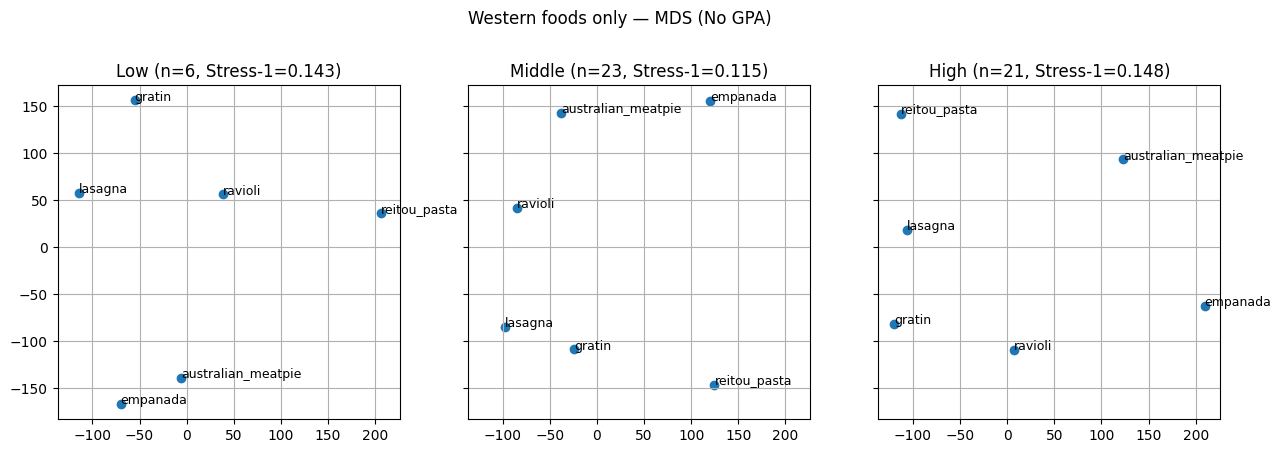

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, g in zip(axes, ["Low","Middle","High"]):
    X = western_group_results[g]["res"][2]["X"]
    s1 = western_group_results[g]["res"][2]["stress1"]
    items = western_group_results[g]["items"]
    n = western_group_results[g]["n"]

    ax.scatter(X[:,0], X[:,1])
    for i, it in enumerate(items):
        ax.text(X[i,0], X[i,1], it, fontsize=9)

    ax.set_title(f"{g} (n={n}, Stress-1={s1:.3f})")
    ax.set_aspect("equal")
    ax.grid(True)

plt.suptitle("Western foods only — MDS (No GPA)")

# === 保存（論文用）===
out_path = Path("image_file_chuo_western_group.png")
fig.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


In [8]:
#被験者ごとの最終配置、クラスター再現

In [9]:
import pandas as pd, json, numpy as np

RAW_PATH = r"/Users/sammy/Desktop/Chu-o/経済学研究科/ゼミ/２年/研究2025/データ/Raw.csv"

# ---------- Responses: moveHistory_json -> last positions ----------
def extract_last_positions_from_movehistory(moveHistory_json):
    try:
        events = json.loads(moveHistory_json)
    except Exception:
        return None
    if not isinstance(events, list):
        return None
    last = {}
    for ev in events:
        if not isinstance(ev, dict):
            continue
        pos = ev.get("position")
        tgt = ev.get("target")
        if isinstance(pos, dict) and tgt is not None:
            x, y = pos.get("x"), pos.get("y")
            if x is None or y is None:
                continue
            try:
                last[str(tgt)] = (float(x), float(y))
            except Exception:
                pass
    return last if last else None

# ---------- Raw: json -> positions ----------
def extract_positions_from_raw_json(o):
    pos_list = o.get("positions", None)
    if not isinstance(pos_list, list) or len(pos_list) == 0:
        return None
    out = {}
    for p in pos_list:
        if not isinstance(p, dict):
            continue
        name = p.get("name")
        x, y = p.get("x"), p.get("y")
        if name is None or x is None or y is None:
            continue
        try:
            out[str(name)] = (float(x), float(y))
        except Exception:
            pass
    return out if out else None

# ---------- signature ----------
def make_signature(pos_dict, quant=10):
    if not isinstance(pos_dict, dict) or len(pos_dict) == 0:
        return None
    items = []
    for k, (x, y) in pos_dict.items():
        xr = int(round(x / quant) * quant)
        yr = int(round(y / quant) * quant)
        items.append((k, xr, yr))
    items.sort()
    return "|".join([f"{k}:{x}:{y}" for k, x, y in items])

# ---------- Raw: clusters_feedback ----------
def extract_clusters_feedback_from_raw_json(o):
    c_list = []
    for c in (o.get("clusters", []) or []):
        if not isinstance(c, dict):
            continue
        fb = c.get("feedback", {}) if isinstance(c.get("feedback", {}), dict) else {}
        cluster_name = (c.get("name") or "").strip() or (fb.get("reasonCreated") or "").strip()
        c_list.append({
            "cluster_name": cluster_name,
            "reasonName": (fb.get("reasonName") or "").strip(),
            "meaning": (fb.get("meaning") or "").strip(),
        })
    return c_list

# ---------- load Raw.csv (header none) ----------
rawlog = pd.read_csv(RAW_PATH, header=None)
assert rawlog.shape[1] >= 4, "Raw.csv は4列目にJSONがある想定（列数が足りない）"

raw_json_strings = rawlog.iloc[:, 3].dropna().astype(str).unique()

raw_rows = []
for s in raw_json_strings:
    try:
        o = json.loads(s)
    except Exception:
        continue
    pos = extract_positions_from_raw_json(o)
    sig = make_signature(pos, quant=10)
    if sig is None:
        continue
    raw_rows.append({
        "sig": sig,
        "clusters_feedback": extract_clusters_feedback_from_raw_json(o),
    })

raw_parsed = pd.DataFrame(raw_rows).drop_duplicates(subset=["sig"], keep="last")
print("raw_parsed signatures:", len(raw_parsed))

# ---------- df side signature ----------
df["sig"] = df["moveHistory_json"].apply(extract_last_positions_from_movehistory).apply(lambda d: make_signature(d, quant=10))
print("df signatures (non-null):", int(df["sig"].notna().sum()))

# ---------- merge by signature ----------
# 既にあっても事故るので消す
for c in ["clusters_feedback", "clusters_feedback_x", "clusters_feedback_y"]:
    if c in df.columns:
        df = df.drop(columns=[c])

df = df.merge(raw_parsed[["sig","clusters_feedback"]], on="sig", how="left")

# clusters_feedback 列が必ず存在するように保証
if "clusters_feedback" not in df.columns:
    df["clusters_feedback"] = None

print("clusters_feedback 欠損率:", float(df["clusters_feedback"].isna().mean()))
print("結合成功件数:", int(df["clusters_feedback"].notna().sum()))


raw_parsed signatures: 51
df signatures (non-null): 50
clusters_feedback 欠損率: 0.0
結合成功件数: 50


In [10]:
def make_subject_html(subject_id, moveHistory_json, recognition_group="", cluster_reasons=None, canvas_size=(900, 650)):
    ...
    if cluster_reasons is None:
        cluster_reasons = {}

    for idx, cl in enumerate(clusters, start=1):
        label = cl.get("label", "")

        # ★ここに書く
        reason = cluster_reasons.get(str(label), "") or cluster_reasons.get(str(idx), "")


In [11]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import IFrame, display

# ==========================================================
# 0) Raw.csv のパス（←ここだけ自分の環境に合わせる）
# ==========================================================
RAW_PATH = r"/Users/sammy/Desktop/Chu-o/経済学研究科/ゼミ/２年/研究2025/データ/Raw.csv"

# ==========================================================
# 1) moveHistory_json / Raw JSON から最終配置を取る
# ==========================================================
def extract_last_positions_from_movehistory(moveHistory_json):
    try:
        events = json.loads(moveHistory_json)
    except Exception:
        return None
    if not isinstance(events, list):
        return None
    last = {}
    for ev in events:
        if not isinstance(ev, dict):
            continue
        pos = ev.get("position")
        tgt = ev.get("target")
        if isinstance(pos, dict) and tgt is not None:
            x, y = pos.get("x"), pos.get("y")
            if x is None or y is None:
                continue
            try:
                last[str(tgt)] = (float(x), float(y))
            except Exception:
                pass
    return last if last else None

def extract_positions_from_raw_json(o):
    pos_list = o.get("positions", None)
    if not isinstance(pos_list, list):
        return None
    out = {}
    for p in pos_list:
        if not isinstance(p, dict):
            continue
        name = p.get("name")
        x, y = p.get("x"), p.get("y")
        if name is None or x is None or y is None:
            continue
        try:
            out[str(name)] = (float(x), float(y))
        except Exception:
            pass
    return out if out else None

# ==========================================================
# 2) 位置指紋(signature)を作る
# ==========================================================
def make_signature(pos_dict, quant=10):
    if not isinstance(pos_dict, dict) or len(pos_dict) == 0:
        return None
    items = []
    for k, (x, y) in pos_dict.items():
        xr = int(round(x / quant) * quant)
        yr = int(round(y / quant) * quant)
        items.append((k, xr, yr))
    items.sort()
    return "|".join([f"{k}:{x}:{y}" for k, x, y in items])

# ==========================================================
# 3) Raw.csv → signature × clusters_feedback
# ==========================================================
def extract_clusters_feedback_from_raw_json(o):
    c_list = []
    for c in (o.get("clusters", []) or []):
        if not isinstance(c, dict):
            continue
        fb = c.get("feedback", {}) if isinstance(c.get("feedback"), dict) else {}
        cluster_name = (c.get("name") or "").strip() or (fb.get("reasonCreated") or "").strip()
        c_list.append({
            "cluster_name": cluster_name,
            "reasonName": (fb.get("reasonName") or "").strip(),
            "meaning": (fb.get("meaning") or "").strip(),
        })
    return c_list

rawlog = pd.read_csv(RAW_PATH, header=None)
raw_json_strings = rawlog.iloc[:, 3].dropna().astype(str).unique()

raw_rows = []
for s in raw_json_strings:
    try:
        o = json.loads(s)
    except Exception:
        continue
    pos = extract_positions_from_raw_json(o)
    sig = make_signature(pos, quant=10)
    if sig is None:
        continue
    raw_rows.append({
        "sig": sig,
        "clusters_feedback": extract_clusters_feedback_from_raw_json(o),
    })

raw_parsed = pd.DataFrame(raw_rows).drop_duplicates(subset=["sig"], keep="last")
print("raw signatures:", len(raw_parsed))

# ==========================================================
# 4) df 側にも signature を作って結合
# ==========================================================
df["sig"] = (
    df["moveHistory_json"]
      .apply(extract_last_positions_from_movehistory)
      .apply(lambda d: make_signature(d, quant=10))
)

# 事故防止
for c in ["clusters_feedback", "clusters_feedback_x", "clusters_feedback_y"]:
    if c in df.columns:
        df = df.drop(columns=[c])

df = df.merge(raw_parsed, on="sig", how="left")

# 必ず列を作る
if "clusters_feedback" not in df.columns:
    df["clusters_feedback"] = None

print("clusters_feedback 欠損率:", float(df["clusters_feedback"].isna().mean()))

# ==========================================================
# 5) 命名理由 extractor（HTML用）
# ==========================================================
def extract_cluster_reasons_from_row(row):
    cfb = row.get("clusters_feedback", None)
    if isinstance(cfb, str):
        try:
            cfb = json.loads(cfb)
        except Exception:
            cfb = None

    out = {}
    if isinstance(cfb, list):
        for c in cfb:
            name = (c.get("cluster_name") or "").strip()
            if not name:
                continue
            reason = (c.get("reasonName") or "").strip()
            meaning = (c.get("meaning") or "").strip()
            parts = []
            if reason:
                parts.append(f"命名理由：{reason}")
            if meaning:
                parts.append(f"意味・定義：{meaning}")
            out[name] = "\n".join(parts) if parts else ""
    return out

# ==========================================================
# 6) クラスター復元（円）
# ==========================================================
def extract_clusters_robust(moveHistory_json):
    try:
        events = json.loads(moveHistory_json)
    except Exception:
        return []
    if not isinstance(events, list):
        return []

    last_draw = None
    clusters = []

    for ev in events:
        if not isinstance(ev, dict):
            continue
        et = ev.get("eventType")
        det = ev.get("details", {}) if isinstance(ev.get("details"), dict) else {}

        if et == "clusterDrawStart":
            last_draw = {
                "centerX": det.get("centerX"),
                "centerY": det.get("centerY"),
            }

        if et == "clusterCreated":
            cx = det.get("centerX")
            cy = det.get("centerY")
            if (cx is None or cy is None) and last_draw:
                cx = last_draw.get("centerX")
                cy = last_draw.get("centerY")

            clusters.append({
                "label": ev.get("target", ""),
                "centerX": cx,
                "centerY": cy,
                "radius": det.get("radius"),
                "itemCount": det.get("itemCount"),
            })
            last_draw = None
    return clusters

# ==========================================================
# 7) HTML生成
# ==========================================================
OUT_DIR = Path("subject_pages_allfoods")
PAGES_DIR = OUT_DIR / "pages"
PAGES_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = ["#e53935","#fdd835","#1e88e5","#43a047","#8e24aa",
           "#fb8c00","#00897b","#6d4c41","#546e7a","#d81b60"]

def color_for_cluster(idx):
    return PALETTE[(idx-1) % len(PALETTE)]

def escape_html(s):
    return str(s).replace("&","&amp;").replace("<","&lt;").replace(">","&gt;")

def wrap_html(title, body):
    return f"""<!doctype html><html><head><meta charset="utf-8"><title>{title}</title></head>
<body style="font-family:sans-serif">{body}</body></html>"""

def make_subject_html(subject_id, row):
    last_pos = extract_last_positions_from_movehistory(row["moveHistory_json"])
    clusters = extract_clusters_robust(row["moveHistory_json"])
    reasons = extract_cluster_reasons_from_row(row)

    svg = []
    for i, cl in enumerate(clusters, 1):
        col = color_for_cluster(i)
        cx, cy, r = cl["centerX"], cl["centerY"], cl["radius"]
        if cx and cy and r:
            svg.append(f'<circle cx="{cx}" cy="{cy}" r="{r}" fill="none" stroke="{col}" stroke-width="3"/>')
            svg.append(f'<text x="{cx}" y="{cy}" fill="{col}" font-size="22">{i}</text>')

    for name,(x,y) in last_pos.items():
        svg.append(f'<circle cx="{x}" cy="{y}" r="6" fill="#111"/>')
        svg.append(f'<text x="{x+8}" y="{y-8}">{escape_html(name)}</text>')

    right = []
    for i, cl in enumerate(clusters, 1):
        lab = cl["label"]
        txt = reasons.get(lab, "（理由なし）")
        right.append(f"<li><b>{i}. {escape_html(lab)}</b><br>{escape_html(txt)}</li>")

    body = f"""
    <h2>Subject {subject_id}</h2>
    <svg width="900" height="650">{''.join(svg)}</svg>
    <h3>クラスター命名理由</h3>
    <ol>{''.join(right)}</ol>
    """
    return wrap_html(f"Subject {subject_id}", body)

rows = []
for idx, r in df.iterrows():
    sid = r.get("subject", str(idx))
    html = make_subject_html(sid, r)
    fname = f"subject_{sid}.html"
    (PAGES_DIR / fname).write_text(html, encoding="utf-8")
    rows.append(f"<li><a href='pages/{fname}'>Subject {sid}</a></li>")

index_html = wrap_html("Index", "<h2>Subjects</h2><ol>"+"".join(rows)+"</ol>")
(OUT_DIR / "index.html").write_text(index_html, encoding="utf-8")

display(IFrame(src=str((OUT_DIR / "index.html").resolve()), width="100%", height=700))


raw signatures: 51
clusters_feedback 欠損率: 0.0


In [12]:
import pandas as pd
import json
import numpy as np

# =========================
# 補助関数
# =========================
def extract_last_positions(moveHistory_json):
    try:
        events = json.loads(moveHistory_json)
    except Exception:
        return {}

    last_pos = {}
    for ev in events:
        if not isinstance(ev, dict):
            continue
        pos = ev.get("position")
        tgt = ev.get("target")
        if isinstance(pos, dict) and tgt is not None:
            x, y = pos.get("x"), pos.get("y")
            if x is not None and y is not None:
                last_pos[str(tgt)] = (float(x), float(y))
    return last_pos

def extract_clusters(moveHistory_json):
    try:
        events = json.loads(moveHistory_json)
    except Exception:
        return []

    clusters = []
    last_draw = None

    for ev in events:
        if not isinstance(ev, dict):
            continue
        et = ev.get("eventType")
        det = ev.get("details", {}) if isinstance(ev.get("details"), dict) else {}

        if et == "clusterDrawStart":
            last_draw = {
                "centerX": det.get("centerX"),
                "centerY": det.get("centerY"),
            }

        if et == "clusterCreated":
            cx = det.get("centerX")
            cy = det.get("centerY")
            if (cx is None or cy is None) and last_draw:
                cx = last_draw.get("centerX")
                cy = last_draw.get("centerY")

            clusters.append({
                "label": ev.get("target", ""),
                "centerX": cx,
                "centerY": cy,
                "radius": det.get("radius"),
            })
            last_draw = None

    return clusters

def items_in_circle(last_pos, cx, cy, r):
    if cx is None or cy is None or r is None:
        return []
    inside = []
    for name, (x, y) in last_pos.items():
        if (x-cx)**2 + (y-cy)**2 <= r**2:
            inside.append(name)
    return sorted(inside)

# =========================
# 集計テーブル作成
# =========================
rows = []

for _, r in df.iterrows():
    subject = r.get("subject")
    last_pos = extract_last_positions(r["moveHistory_json"])
    clusters = extract_clusters(r["moveHistory_json"])

    for idx, cl in enumerate(clusters, start=1):
        items = items_in_circle(
            last_pos,
            cl["centerX"],
            cl["centerY"],
            cl["radius"]
        )

        rows.append({
            "subject": subject,
            "cluster_idx": idx,
            "cluster_label": cl["label"],
            "items": items,
            "items_str": ", ".join(items)
        })

cluster_items_df = pd.DataFrame(rows)
cluster_items_df.head()


,subject,cluster_idx,cluster_label,items,items_str
0,1763202024623_e84e9ae9,1,身近な和食や中華系,"[chahan, gyoza, karaage, reitou_udon]","chahan, gyoza, karaage, reitou_udon"
1,1763202024623_e84e9ae9,2,日本で売ってる洋食,"[gratin, lasagna]","gratin, lasagna"
2,1763202024623_e84e9ae9,3,馴染みがない,"[australian_meatpie, empanada]","australian_meatpie, empanada"
3,1764397403362_bd838f1b,1,海外料理,"[australian_meatpie, empanada]","australian_meatpie, empanada"
4,1764397403362_bd838f1b,2,おかずの一品、お酒のおつまみ,[gyoza],gyoza


In [13]:
meatpie_df = cluster_items_df[
    cluster_items_df["items"].apply(lambda xs: "australian_meatpie" in xs)
]

meatpie_df.head()


,subject,cluster_idx,cluster_label,items,items_str
2,1763202024623_e84e9ae9,3,馴染みがない,"[australian_meatpie, empanada]","australian_meatpie, empanada"
3,1764397403362_bd838f1b,1,海外料理,"[australian_meatpie, empanada]","australian_meatpie, empanada"
6,1764397403362_bd838f1b,4,一皿料理,"[australian_meatpie, lasagna, ravioli, reitou_...","australian_meatpie, lasagna, ravioli, reitou_p..."
8,1764173147762_3dc846f4,1,クラスター1,"[australian_meatpie, empanada, gratin, lasagna...","australian_meatpie, empanada, gratin, lasagna,..."
10,1763264588619_7ffc04a7,1,クラスター1,"[australian_meatpie, gratin, lasagna, ravioli,...","australian_meatpie, gratin, lasagna, ravioli, ..."


In [14]:
import pandas as pd
from collections import Counter

# meatpie_df はすでに作ってある前提（australian_meatpie を含むクラスター行のみ）
co = Counter()
for items in meatpie_df["items"]:
    for it in items:
        if it != "australian_meatpie":
            co[it] += 1

co_df = (pd.DataFrame(co.items(), columns=["item","count"])
           .sort_values("count", ascending=False)
           .reset_index(drop=True))

co_df.head(20)


,item,count
0,lasagna,28
1,empanada,26
2,ravioli,26
3,gratin,25
4,reitou_pasta,18
5,gyoza,4
6,karaage,3
7,reitou_udon,2
8,yakionigiri,2
9,chahan,1


In [15]:
label_freq = (meatpie_df["cluster_label"]
              .fillna("")
              .astype(str)
              .str.strip()
              .replace("", "（無記名）")
              .value_counts()
              .reset_index())
label_freq.columns = ["cluster_label", "n"]
label_freq.head(30)


,cluster_label,n
0,洋食,4
1,ミートソース使用,2
2,クラスター1,2
3,ミートソース,2
4,洋風の食べ物,2
5,馴染みがない,1
6,クラスター2,1
7,海外,1
8,トマト,1
9,ひき肉ベースの欧米の料理,1


In [16]:
def reasons_text_from_clusters_feedback(row):
    cfb = row.get("clusters_feedback", None)
    if isinstance(cfb, str):
        try:
            cfb = json.loads(cfb)
        except Exception:
            cfb = None

    # {cluster_name: text}
    mp = {}
    if isinstance(cfb, list):
        for c in cfb:
            name = (c.get("cluster_name") or "").strip()
            if not name:
                continue
            reason = (c.get("reasonName") or "").strip()
            meaning = (c.get("meaning") or "").strip()
            parts = []
            if reason:
                parts.append(f"命名理由：{reason}")
            if meaning:
                parts.append(f"意味・定義：{meaning}")
            mp[name] = "\n".join(parts) if parts else ""
    return mp

# df側から {subject -> reasons_map} を作って付与
tmp = df[["subject","clusters_feedback"]].copy()
tmp["reasons_map"] = tmp.apply(reasons_text_from_clusters_feedback, axis=1)

# meatpie_df と結合（subject単位）
meatpie_detail = meatpie_df.merge(tmp[["subject","reasons_map"]], on="subject", how="left")

# ラベルに対応する理由を引く
def pick_reason(row):
    lab = str(row["cluster_label"]).strip()
    mp = row.get("reasons_map", {}) or {}
    return mp.get(lab, "")

meatpie_detail["reason_text"] = meatpie_detail.apply(pick_reason, axis=1)

meatpie_detail[["subject","cluster_label","items_str","reason_text"]].head(20)


,subject,cluster_label,items_str,reason_text
0,1763202024623_e84e9ae9,馴染みがない,"australian_meatpie, empanada",命名理由：思ったことをそのまま名前にしました。\n意味・定義：海外のものだとみんな思うと考えます。
1,1764397403362_bd838f1b,海外料理,"australian_meatpie, empanada",命名理由：グループの特徴をそのまま名前にしました。\n意味・定義：海外料理の王道な主食メニュ...
2,1764397403362_bd838f1b,一皿料理,"australian_meatpie, lasagna, ravioli, reitou_p...",命名理由：一皿で主食として成り立つのでその名前をつけました。\n意味・定義：一品で完結するた...
3,1764173147762_3dc846f4,クラスター1,"australian_meatpie, empanada, gratin, lasagna,...",命名理由：名前を変えるのことをミスった\n付けるとするなら\n「西洋への憧れ」とでもしましょ...
4,1763264588619_7ffc04a7,クラスター1,"australian_meatpie, gratin, lasagna, ravioli, ...",命名理由：全体の中で最も基本的かつ代表的な洋食系のカテゴリーだと考えたから\n意味・定義：便...
5,1763203283549_650dc654,オーブンを用いた調理法の料理,"australian_meatpie, lasagna, ravioli",命名理由：あまり日常では口にしない料理が多いと感じたため。\n意味・定義：このグループは「珍...
6,1763203283549_650dc654,主食として食べることができる料理,"australian_meatpie, chahan, gratin, lasagna, r...",命名理由：主食としてボリュームがあると考えたため。\n意味・定義：「1品でおなか一杯になる」...
7,1764518426676_db659461,洋食,"australian_meatpie, gratin, lasagna, ravioli, ...",命名理由：共通点であるため\n意味・定義：ファミリーレストランに出てきそう
8,1763191020144_34611dd6,主食にならない,"australian_meatpie, empanada, gyoza, karaage",命名理由：グループの特徴を一言で表したからです。\n意味・定義：このグループは「おかずに一品...
9,1764408443943_482b07cc,小麦粉製品,"australian_meatpie, empanada, gratin, gyoza, l...",命名理由：特徴をそのまま名前にした。\n意味・定義：麺類と包む系の料理の多くは小麦粉を使用し...


In [17]:
# =========================
# 保存用：結果をすべてファイルに書き出す
# =========================
import os
from pathlib import Path

# 保存先（ノートブックと同じ場所にフォルダを作る）
OUT_DIR = Path("analysis_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1) 被験者×クラスター×食品（全体）
if "cluster_items_df" in globals():
    cluster_items_df.to_csv(
        OUT_DIR / "cluster_items_all_subjects.csv",
        index=False, encoding="utf-8-sig"
    )

# 2) ミートパイを含むクラスター（抽出）
if "meatpie_df" in globals():
    meatpie_df.to_csv(
        OUT_DIR / "meatpie_clusters_only.csv",
        index=False, encoding="utf-8-sig"
    )

# 3) ミートパイ共起ランキング
if "co_df" in globals():
    co_df.to_csv(
        OUT_DIR / "meatpie_cooccurrence.csv",
        index=False, encoding="utf-8-sig"
    )

# 4) クラスター名（ラベル）頻度
if "label_freq" in globals():
    label_freq.to_csv(
        OUT_DIR / "meatpie_cluster_label_freq.csv",
        index=False, encoding="utf-8-sig"
    )

# 5) 命名理由つき（最重要：手動コーディング用）
if "meatpie_detail" in globals():
    meatpie_detail.to_csv(
        OUT_DIR / "meatpie_cluster_detail_with_reasons.csv",
        index=False, encoding="utf-8-sig"
    )

print("Saved files to:", OUT_DIR.resolve())
print("Files:", [p.name for p in OUT_DIR.iterdir()])


Saved files to: /Users/sammy/projects/food-mapping/analysis_outputs
Files: ['meatpie_cluster_label_freq.csv', 'cluster_items_all_subjects.csv', 'meatpie_clusters_only.csv', 'meatpie_cluster_detail_with_reasons.csv', 'meatpie_cooccurrence.csv']


In [18]:
名前理由

NameError: name '名前理由' is not defined

In [23]:
import pandas as pd

coded = pd.read_csv(
    r"/Users/sammy/Desktop/Chu-o/経済学研究科/ゼミ/２年/研究2025/データ/meatpie_cluster_detail_with_reasons.csv",
    encoding="utf-8"
)

coded.head()


,subject,cluster_idx,cluster_label,meaning_category,items,items_str,reasons_map,reason_text
0,1763202024623_e84e9ae9,3,馴染みがない,馴染みがない,"['australian_meatpie', 'empanada']","australian_meatpie, empanada",{'身近な和食や中華系': '命名理由：特徴をそのまま名前にしました。\n意味・定義：無難で...,命名理由：思ったことをそのまま名前にしました。\n意味・定義：海外のものだとみんな思うと考えます。
1,1764397403362_bd838f1b,1,海外料理,洋食,"['australian_meatpie', 'empanada']","australian_meatpie, empanada",{'海外料理': '命名理由：グループの特徴をそのまま名前にしました。\n意味・定義：海外料...,命名理由：グループの特徴をそのまま名前にしました。\n意味・定義：海外料理の王道な主食メニュ...
2,1764397403362_bd838f1b,4,一皿料理,主食,"['australian_meatpie', 'lasagna', 'ravioli', '...","australian_meatpie, lasagna, ravioli, reitou_p...",{'海外料理': '命名理由：グループの特徴をそのまま名前にしました。\n意味・定義：海外料...,命名理由：一皿で主食として成り立つのでその名前をつけました。\n意味・定義：一品で完結するた...
3,1764173147762_3dc846f4,1,西洋への憧れ,洋食,"['australian_meatpie', 'empanada', 'gratin', '...","australian_meatpie, empanada, gratin, lasagna,...",{'クラスター1': '命名理由：名前を変えるのことをミスった\n付けるとするなら\n「西洋...,命名理由：名前を変えるのことをミスった\n付けるとするなら\n「西洋への憧れ」とでもしましょ...
4,1763264588619_7ffc04a7,1,クラスター1,クラスター,"['australian_meatpie', 'gratin', 'lasagna', 'r...","australian_meatpie, gratin, lasagna, ravioli, ...",{'クラスター1': '命名理由：全体の中で最も基本的かつ代表的な洋食系のカテゴリーだと考え...,命名理由：全体の中で最も基本的かつ代表的な洋食系のカテゴリーだと考えたから\n意味・定義：便...


In [24]:
cat_freq = (
    coded["meaning_category"]
    .fillna("未分類")
    .value_counts()
    .reset_index()
)

cat_freq.columns = ["meaning_category", "n"]
cat_freq["ratio"] = (cat_freq["n"] / cat_freq["n"].sum()).round(3)

cat_freq


,meaning_category,n,ratio
0,洋食,16,0.32
1,ミートソース,8,0.16
2,包む料理,5,0.10
3,馴染みがない,4,0.08
4,小麦粉料理,2,0.04
5,クラスター,2,0.04
6,主食,2,0.04
7,馴染みがない料理,2,0.04
8,オーブン料理,1,0.02
9,非洋食,1,0.02


In [25]:
cat_freq.to_csv(
    r"/Users/sammy/Desktop/Chu-o/経済学研究科/ゼミ/２年/研究2025/データ/meatpie_meaning_category_frequency.csv",
    index=False,
    encoding="utf-8-sig"
)


df.columns = ['submission_id', 'moveHistory_json', 'recognition:australian_meatpie', 'recognition_group', 'subject', 'clusters_feedback']
clusters_feedback列として 'clusters_feedback' を使用します。


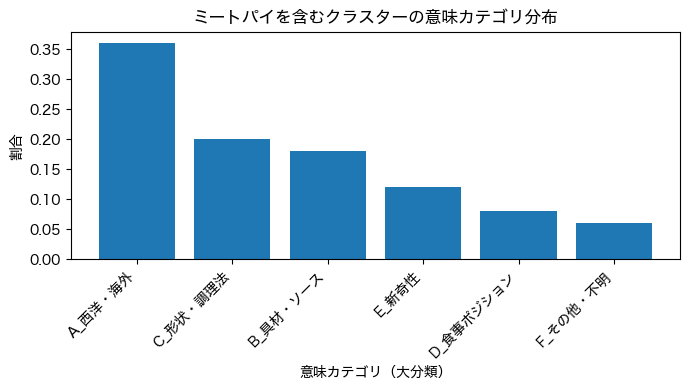

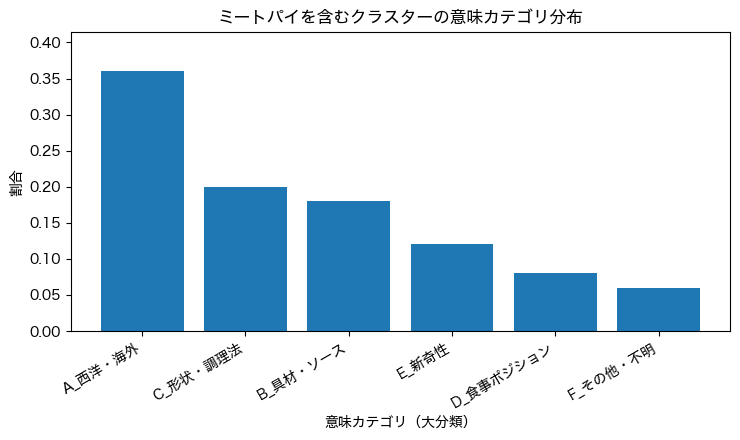

Saved: meatpie_meaning_category_dist.png


In [32]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from collections import Counter

# Macで最も安定
rcParams["font.family"] = "Hiragino Sans"

# もし表示されなければ下を試す
# rcParams["font.family"] = "IPAexGothic"
# rcParams["font.family"] = "Hiragino Kaku Gothic ProN"

def extract_last_positions(moveHistory_json):
    try:
        events = json.loads(moveHistory_json)
    except Exception:
        return {}

    last_pos = {}
    for ev in events:
        if not isinstance(ev, dict):
            continue
        pos = ev.get("position")
        tgt = ev.get("target")
        if isinstance(pos, dict) and tgt is not None:
            x, y = pos.get("x"), pos.get("y")
            if x is not None and y is not None:
                last_pos[str(tgt)] = (float(x), float(y))
    return last_pos


def extract_clusters(moveHistory_json):
    try:
        events = json.loads(moveHistory_json)
    except Exception:
        return []

    clusters = []
    last_draw = None

    for ev in events:
        if not isinstance(ev, dict):
            continue

        et = ev.get("eventType")
        det = ev.get("details", {}) if isinstance(ev.get("details"), dict) else {}

        if et == "clusterDrawStart":
            last_draw = {
                "centerX": det.get("centerX"),
                "centerY": det.get("centerY"),
            }

        if et == "clusterCreated":
            cx = det.get("centerX")
            cy = det.get("centerY")
            if (cx is None or cy is None) and last_draw:
                cx = last_draw.get("centerX")
                cy = last_draw.get("centerY")

            clusters.append({
                "label": ev.get("target", ""),
                "centerX": cx,
                "centerY": cy,
                "radius": det.get("radius"),
            })
            last_draw = None

    return clusters


def items_in_circle(last_pos, cx, cy, r):
    if cx is None or cy is None or r is None:
        return []
    inside = []
    for name, (x, y) in last_pos.items():
        if (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2:
            inside.append(name)
    return sorted(inside)

rows = []

for _, r in df.iterrows():
    subject = r.get("subject")
    last_pos = extract_last_positions(r["moveHistory_json"])
    clusters = extract_clusters(r["moveHistory_json"])

    for idx, cl in enumerate(clusters, start=1):
        items = items_in_circle(
            last_pos,
            cl["centerX"],
            cl["centerY"],
            cl["radius"]
        )

        rows.append({
            "subject": subject,
            "cluster_idx": idx,
            "cluster_label": cl["label"],
            "items": items,
            "items_str": ", ".join(items)
        })

cluster_items_df = pd.DataFrame(rows)

meatpie_df = cluster_items_df[
    cluster_items_df["items"].apply(lambda xs: "australian_meatpie" in xs)
]

co = Counter()
for items in meatpie_df["items"]:
    for it in items:
        if it != "australian_meatpie":
            co[it] += 1

co_df = (
    pd.DataFrame(co.items(), columns=["item", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

label_freq = (
    meatpie_df["cluster_label"]
    .fillna("")
    .astype(str)
    .str.strip()
    .replace("", "（無記名）")
    .value_counts()
    .reset_index()
)
label_freq.columns = ["cluster_label", "n"]

def reasons_text_from_clusters_feedback(row):
    cfb = row.get("clusters_feedback", None)
    if isinstance(cfb, str):
        try:
            cfb = json.loads(cfb)
        except Exception:
            cfb = None

    mp = {}
    if isinstance(cfb, list):
        for c in cfb:
            name = (c.get("cluster_name") or "").strip()
            if not name:
                continue
            reason = (c.get("reasonName") or "").strip()
            meaning = (c.get("meaning") or "").strip()

            parts = []
            if reason:
                parts.append(f"命名理由：{reason}")
            if meaning:
                parts.append(f"意味・定義：{meaning}")

            mp[name] = "\n".join(parts) if parts else ""

    return mp

# =========================
# clusters_feedback 列の安全な取得（列名違い/欠落に対応）
# =========================

# dfに存在する列名を一度確認（任意：デバッグ用）
print("df.columns =", list(df.columns))

# 候補になりそうな列名を広めに用意（必要なら追加してOK）
CANDIDATES = [
    "clusters_feedback",
    "cluster_feedback",
    "clustersFeedback",
    "clusters_feedback_json",
    "clustersFeedback_json",
    "cluster_feedback_json",
    "clusterFeedback",
]

feedback_col = None
for c in CANDIDATES:
    if c in df.columns:
        feedback_col = c
        break

if feedback_col is None:
    # 見つからない場合は「空の列」を作って処理を継続（落とさない）
    print("WARNING: clusters_feedback系の列が見つかりません。理由テキストは空になります。")
    df = df.copy()
    df["clusters_feedback"] = None
    feedback_col = "clusters_feedback"
else:
    print(f"clusters_feedback列として '{feedback_col}' を使用します。")


tmp = df[["subject", feedback_col]].copy()
tmp = tmp.rename(columns={feedback_col: "clusters_feedback"})
tmp["reasons_map"] = tmp.apply(reasons_text_from_clusters_feedback, axis=1)

meatpie_detail = meatpie_df.merge(
    tmp[["subject", "reasons_map"]],
    on="subject",
    how="left"
)


def pick_reason(row):
    lab = str(row["cluster_label"]).strip()
    mp = row.get("reasons_map", {}) or {}
    return mp.get(lab, "")


meatpie_detail["reason_text"] = meatpie_detail.apply(pick_reason, axis=1)

coded = pd.read_csv(
    "/Users/sammy/Desktop/Chu-o/経済学研究科/ゼミ/２年/研究2025/データ/meatpie_cluster_detail_with_reasons.csv",
    encoding="utf-8"
)

MAP = {
    "洋食": "A_西洋・海外",
    "非洋食": "A_西洋・海外",
    "特別な料理": "A_西洋・海外",

    "ミートソース": "B_具材・ソース",
    "トマト料理": "B_具材・ソース",

    "包む料理": "C_形状・調理法",
    "小麦粉料理": "C_形状・調理法",
    "オーブン料理": "C_形状・調理法",
    "形と材料が似ている": "C_形状・調理法",
    "カリッとした食感": "C_形状・調理法",

    "主食": "D_食事ポジション",
    "主食・副食になりうる料理": "D_食事ポジション",
    "手軽に食べられる料理": "D_食事ポジション",

    "馴染みがない": "E_新奇性",
    "馴染みがない料理": "E_新奇性",
}

coded["meaning_category_big"] = coded["meaning_category"].map(MAP).fillna("F_その他・不明")

big_freq = (
    coded["meaning_category_big"]
    .value_counts()
    .reset_index()
)
big_freq.columns = ["meaning_category_big", "n"]
big_freq["ratio"] = (big_freq["n"] / big_freq["n"].sum()).round(3)

plt.figure(figsize=(7,4))
plt.bar(big_freq["meaning_category_big"], big_freq["ratio"])
plt.ylabel("割合")
plt.xlabel("意味カテゴリ（大分類）")
plt.title("ミートパイを含むクラスターの意味カテゴリ分布")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
from matplotlib import rcParams

# -------------------------
# 日本語フォント（Macで安定）
# -------------------------
rcParams["font.family"] = "Hiragino Sans"  # もしダメなら IPAexGothic 等に変更

# -------------------------
# 並び順（ratioの降順にして見やすく）
# -------------------------
bf = big_freq.copy()
bf = bf.sort_values("ratio", ascending=False)

# -------------------------
# 図の作成
# -------------------------
plt.figure(figsize=(7.5, 4.5))
plt.bar(bf["meaning_category_big"], bf["ratio"])

plt.ylabel("割合")
plt.xlabel("意味カテゴリ（大分類）")
plt.title("ミートパイを含むクラスターの意味カテゴリ分布")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, max(bf["ratio"]) * 1.15)  # 少し上に余白

plt.tight_layout()

# -------------------------
# 保存（論文向け）
# -------------------------
out_name = "meatpie_meaning_category_dist.png"
plt.savefig(out_name, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_name)


low_long shape: (66, 5)
low subjects: 6
Low group subjects: ['1763202024623_e84e9ae9', '1763108480694_0b6767e1', '1764547304968_b28e90d1', '1764594352477_b85d00b1', '1764831308855_a620197d', '1764914504831_dd7f1f7d']


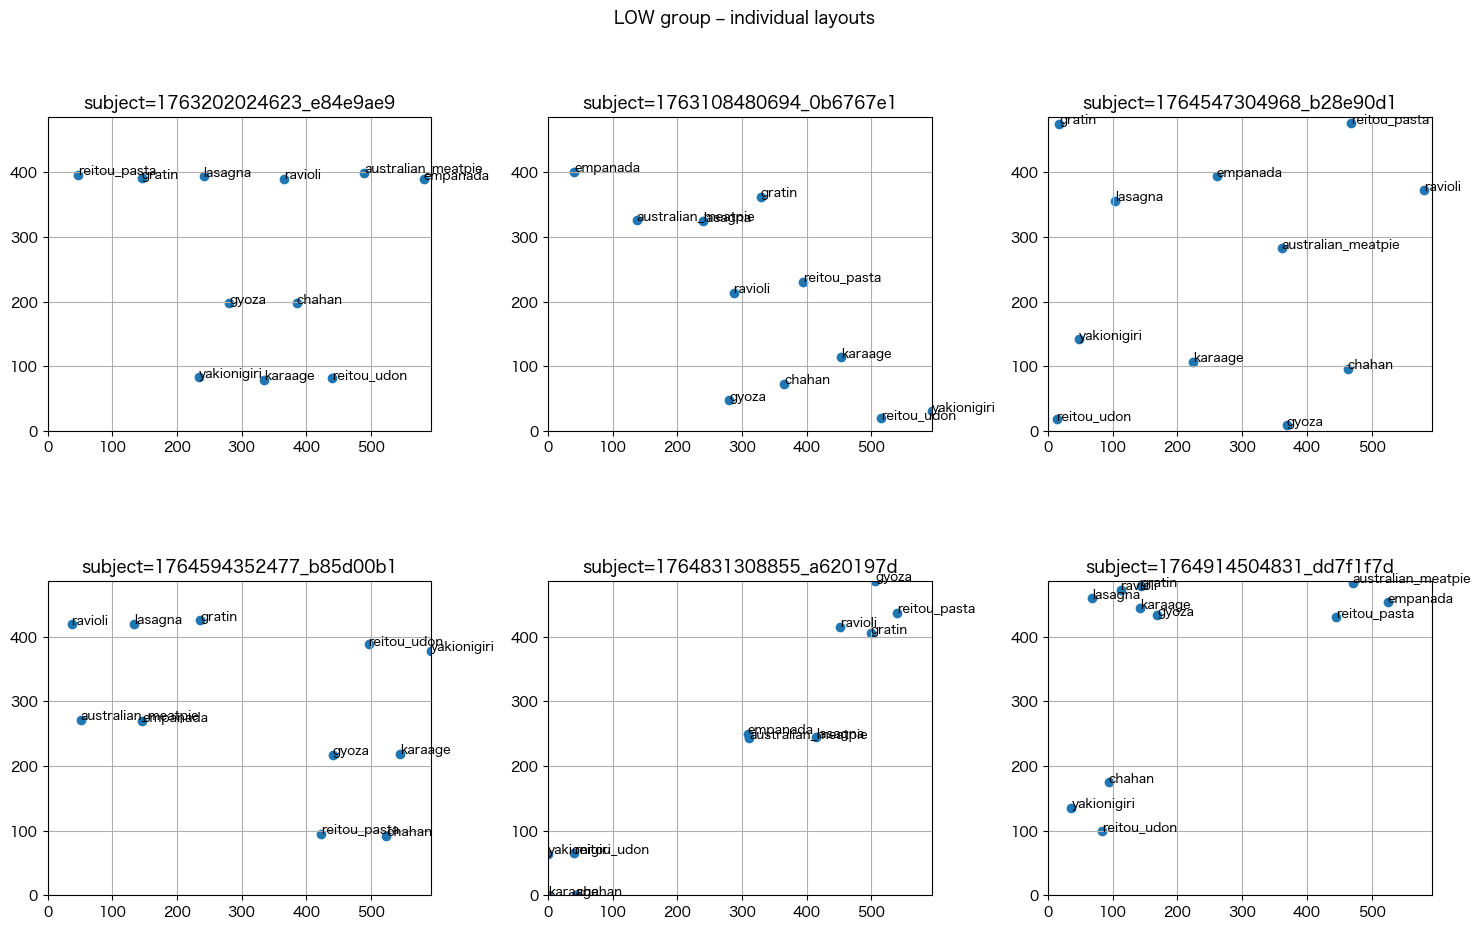

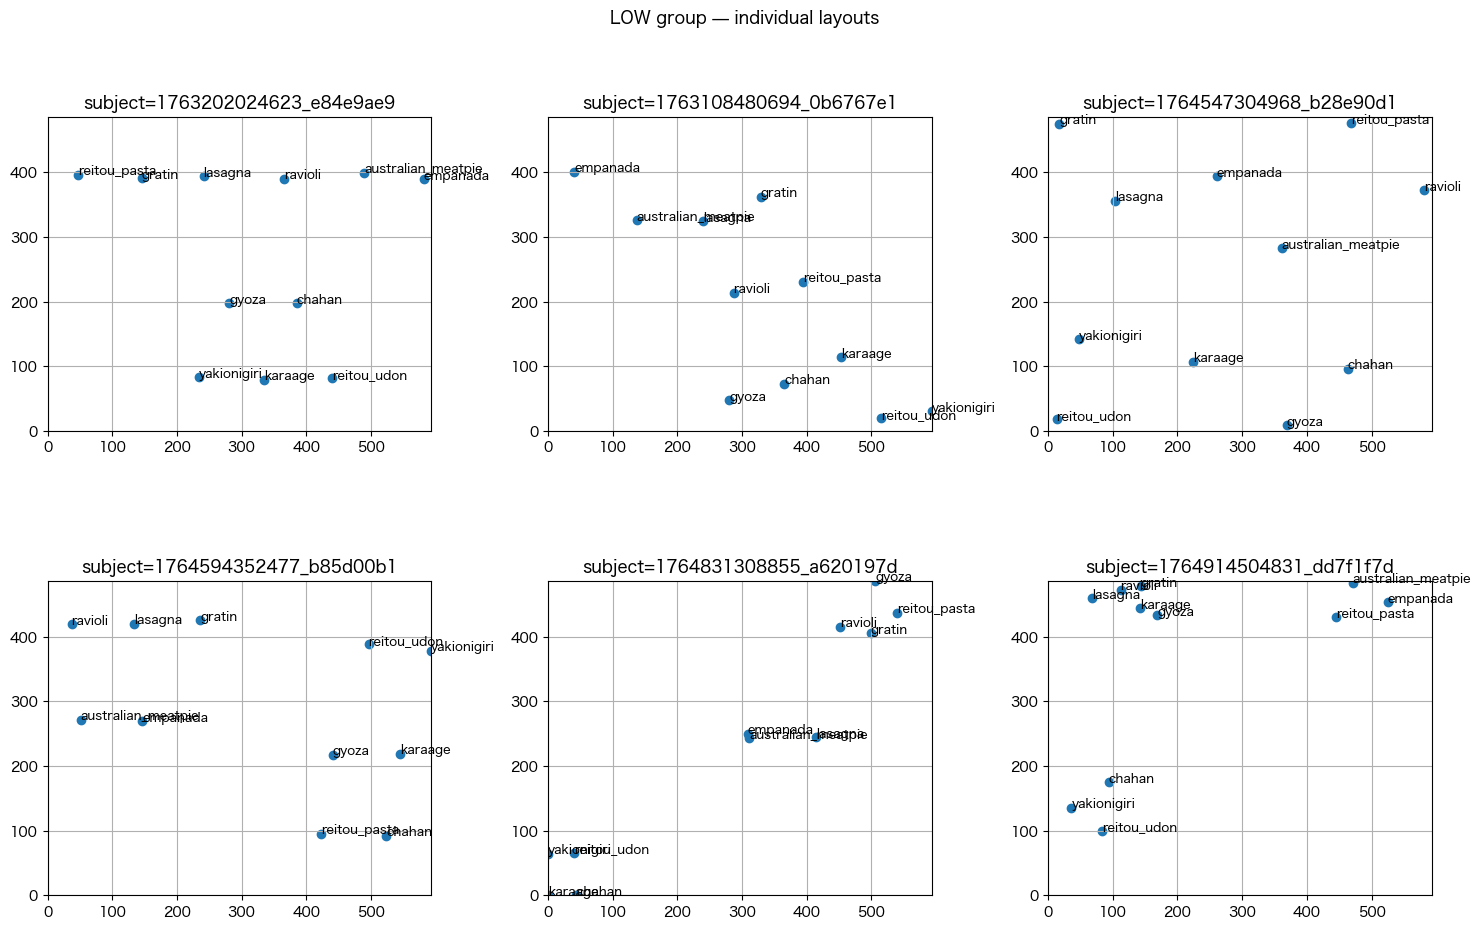

In [34]:
import math
import matplotlib.pyplot as plt

# Low群の long_df を作る
low_long = long_df[
    long_df["recognition_group"].astype(str).str.strip() == "Low"
].copy()

print("low_long shape:", low_long.shape)
print("low subjects:", low_long["subject"].nunique())

low_subjects = (
    low_long["subject"]
    .astype(str)
    .dropna()
    .unique()
    .tolist()
)

print("Low group subjects:", low_subjects)

plot_group_subjects_grid(
    low_long,
    low_subjects,
    ncols=3,
    suptitle="LOW group – individual layouts"
)


def plot_group_subjects_grid(long_df_in, subject_ids, ncols=3, suptitle=""):
    n = len(subject_ids)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
    axes = axes.flatten() if n > 1 else [axes]

    # 全員で軸を揃える（比較しやすい）
    all_sub = long_df_in[long_df_in["subject"].isin(list(map(str, subject_ids)))]
    xmin, xmax = all_sub["x"].min(), all_sub["x"].max()
    ymin, ymax = all_sub["y"].min(), all_sub["y"].max()

    for ax, sid in zip(axes, subject_ids):
        sub = long_df_in[long_df_in["subject"] == str(sid)]
        ax.scatter(sub["x"], sub["y"])
        for _, r in sub.iterrows():
            ax.text(r["x"], r["y"], r["item"], fontsize=9)
        ax.set_title(f"subject={sid}")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.grid(True)

    # 余り枠を消す
    for k in range(len(subject_ids), len(axes)):
        axes[k].axis("off")

    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

plot_group_subjects_grid(low_long, low_subjects, ncols=3, suptitle="LOW group — individual layouts")
